In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

2.12.0
False


In [6]:
import os

print(os.getcwd())

/Users/jiheneguesmi/Desktop/machine_learning/smart_agriculture/notebooks


In [7]:
os.listdir()

['.ipynb_checkpoints', '01_dataset_exploration.ipynb']

In [8]:
import os
import cv2
import matplotlib.pyplot as plt

# Example image path
image_path = "../data/detection/train/images"

images = os.listdir(image_path)
print("hello")
print("Number of images:", len(images))

hello
Number of images: 4685


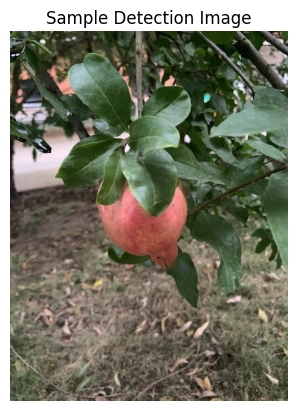

In [9]:
sample_image = os.path.join(image_path, images[0])

img = cv2.imread(sample_image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Sample Detection Image")
plt.axis("off")
plt.show()

In [10]:
# dataset statisctis 
print("Total Images:", len(images))

Total Images: 4685


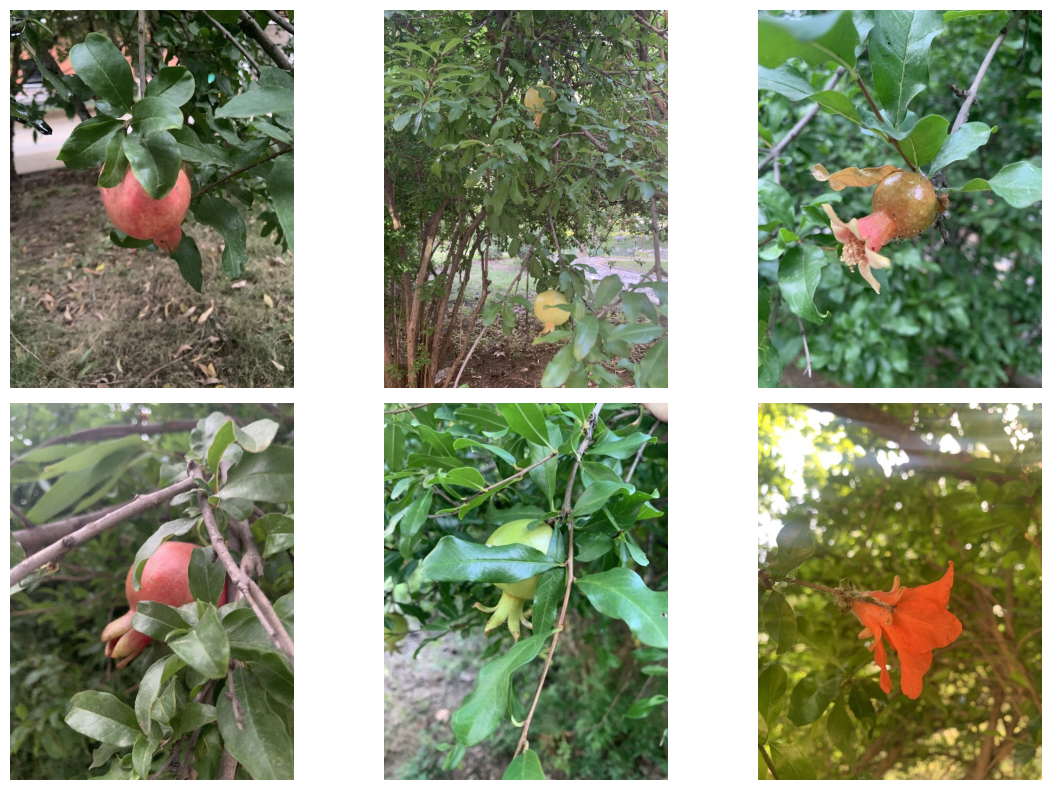

In [11]:
#display multiple simples 
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    img_path = os.path.join(image_path, images[i])

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
#analyse images sizes
widths = []
heights = []

for img_name in images[:100]:
    img_path = os.path.join(image_path, img_name)

    img = cv2.imread(img_path)

    h, w, _ = img.shape

    widths.append(w)
    heights.append(h)

print("Average Width:", sum(widths)/len(widths))
print("Average Height:", sum(heights)/len(heights))

Average Width: 515.2
Average Height: 604.8


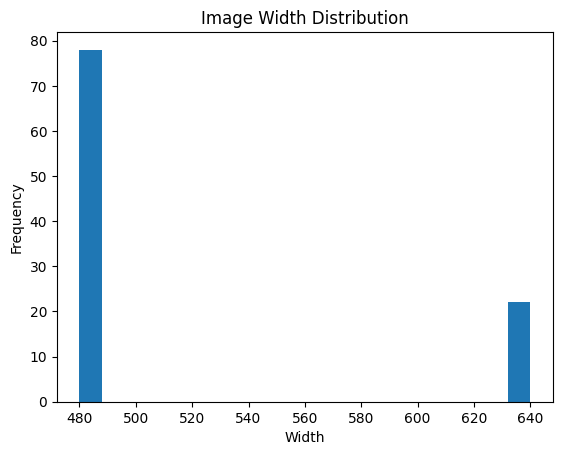

In [13]:
#districbution visualization  widht 
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")
plt.show()

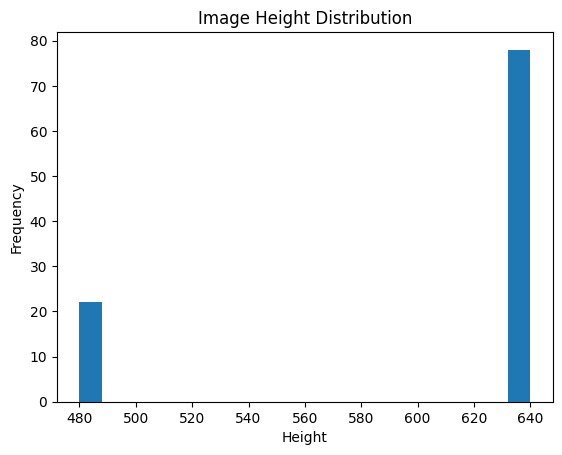

In [14]:
# distribution visualisation  height 
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

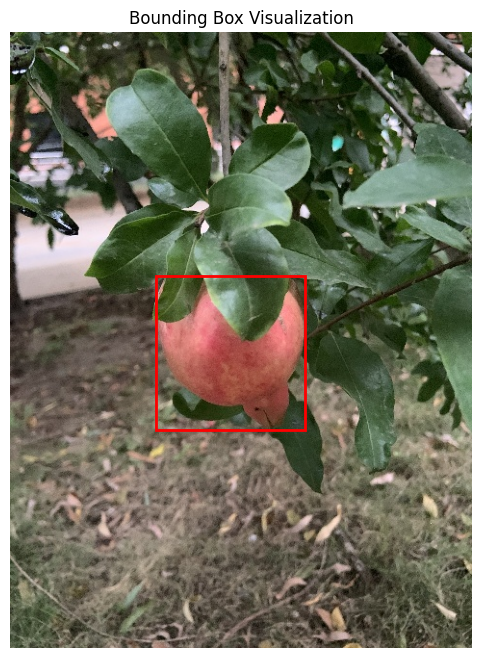

In [15]:
# bounding box 
import matplotlib.patches as patches

# Select sample image
sample_image_name = images[0]

# Paths
img_path = os.path.join(image_path, sample_image_name)

label_path = img_path.replace("images", "labels")
label_path = os.path.splitext(label_path)[0] + ".txt"

# Read image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w, _ = img.shape

# Create plot
fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(img)

# Read YOLO labels
with open(label_path, "r") as f:
    labels = f.readlines()

for label in labels:
    cls, x_center, y_center, box_w, box_h = map(float, label.split())

    # Convert YOLO format to rectangle coordinates
    x1 = (x_center - box_w / 2) * w
    y1 = (y_center - box_h / 2) * h

    rect_w = box_w * w
    rect_h = box_h * h

    rect = patches.Rectangle(
        (x1, y1),
        rect_w,
        rect_h,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )

    ax.add_patch(rect)

plt.title("Bounding Box Visualization")
plt.axis("off")
plt.show()

In [16]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [18]:
# augremention pipeline
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Rotate(limit=20, p=0.5),
    A.Blur(blur_limit=3, p=0.2),
])

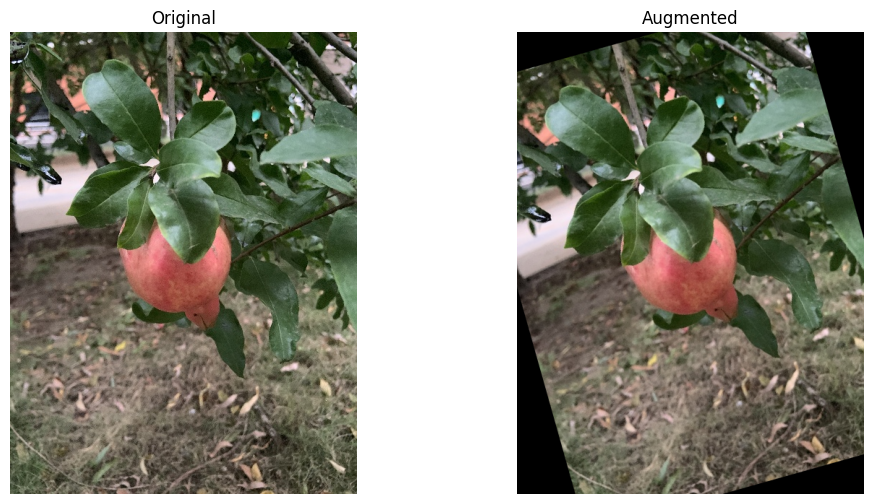

In [19]:
#augmention
sample_image = images[0]

img_path = os.path.join(image_path, sample_image)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

augmented = transform(image=img)

augmented_image = augmented["image"]

# Display original and augmented
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(augmented_image)
axes[1].set_title("Augmented")
axes[1].axis("off")

plt.show()